# 국민여행조사 리사이징 데이터 전처리 (`out-traveler` repo 기준)
- 데이터 소스: `out-traveler/data/raw/combined_2024_2025.csv` (2024/2025 통합본 하나만 사용)
- 이전 버전에서는 `2024_resized.csv` / `2025_resized.csv`를 각각 검증한 뒤 합쳐서 통합본을 만들었는데, 검증 결과 두 연도 다 중복·연도불일치 등 손상 레코드가 0건이었기 때문에 **굳이 나눠서 처리할 필요가 없었음**
- 그래서 이번 버전은 `combined_2024_2025.csv` **하나만** 불러와서 전처리 → 파생변수 → 저장까지 한 번에 진행함
- 분석 4가지(방문집중도×지출, 4분면 유형화, 지원금 관계분석, 우선순위 도출)는 전부 이 통합 파일 하나로 수행 가능. 연도별로 나눠 보고 싶을 때는 `year` 컬럼으로 필터링하면 됨
- 처리 완료된 최종 파일은 `out-traveler/data/processed/eunyoung_combined_2024_2025_processed.csv`로 저장
- 참고 문서: `리사이징_실행결과_요약.pdf`, `2024/2025년_국민여행조사_코드북.pdf`
- 이 노트북 위치: `out-traveler/notebooks/eda/eda_eunyoung.ipynb` → repo 루트에서 2단계 아래이므로 상대경로는 `../../data/...`로 설정함

In [1]:
1+1 # 커널 작동 확인

2

## 1. 데이터 불러오기

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

RAW_PATH = '../../data/raw/combined_2024_2025.csv'
df = pd.read_csv(RAW_PATH)
print(df.shape)
df.head()

(103939, 82)


,ID,WT_DOM,BSEX,BAGE,BINC1,D_TRA1_SYEAR,D_TRA1_SMONTH,D_TRA1_1_SPOT,D_TRA1_CASE,D_TRA1_COST,...,국내_A_여행지출_관광전체_경기,국내_A_여행지출_관광전체_강원,국내_A_여행지출_관광전체_충북,국내_A_여행지출_관광전체_충남,국내_A_여행지출_관광전체_전북,국내_A_여행지출_관광전체_전남,국내_A_여행지출_관광전체_경북,국내_A_여행지출_관광전체_경남,국내_A_여행지출_관광전체_제주,연도
0,11010550271_275001,23089.477138,1,5,7,NaN,NaN,NaN,NaN,NaN,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,2024
1,11010550271_275003,12692.053111,1,4,7,2024.0,1.0,32030.0,1.0,1020006.0,...,0.0,340002.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,2024
2,11010550271_275004,18181.119131,1,3,5,2024.0,1.0,32030.0,1.0,909999.0,...,0.0,303333.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,2024
3,11010550271_275007,19038.079666,1,4,6,NaN,NaN,NaN,NaN,NaN,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,2024
4,11010550271_275008,24343.187611,2,2,7,NaN,NaN,NaN,NaN,NaN,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,2024


## 회차별 필드(1~6차) 타입 변환: float → Int64
- `D_TRAn_SYEAR/SMONTH/1_SPOT/CASE/COST/NUM/ONE_COST`(n=1~6, 총 42개 컬럼)는 원래 값 자체는 전부 정수(코드·개수·금액)인데, 결측치(NaN)가 섞여 있으면 pandas가 자동으로 float64로 저장함(numpy 기본 int는 NaN을 표현 못 함)
- 그대로 두면 태블로에서 `D_TRA1_1_SPOT`(방문지역 코드) 같은 값이 `31030.0`처럼 소수점이 붙어서 보여 가독성이 떨어짐
- **CSV를 읽어온 직후, 뒤 분석에 들어가기 전에** pandas의 nullable 정수 타입 `Int64`(대문자 I)로 미리 변환 → NaN은 유지하면서 정수로 저장되게 함
- `WT_DOM`(가중치), `국내_A_여행지출_관광전체_*`(지역별 지출)처럼 **실제로 소수점이 있는 컬럼은 대상에서 제외**

In [3]:
# 1~6차 회차별 필드 전체 컬럼 목록 생성 (7개 필드 x 6회차 = 42개, 2024는 6차가 원래 없어서 전부 NaN이지만 컬럼 자체는 존재)
round_fields = ['SYEAR', 'SMONTH', '1_SPOT', 'CASE', 'COST', 'NUM', 'ONE_COST']
round_int_cols = [f'D_TRA{n}_{field}' for n in range(1, 7) for field in round_fields]

print('변환 대상 컬럼 수:', len(round_int_cols))
print(round_int_cols)

변환 대상 컬럼 수: 42
['D_TRA1_SYEAR', 'D_TRA1_SMONTH', 'D_TRA1_1_SPOT', 'D_TRA1_CASE', 'D_TRA1_COST', 'D_TRA1_NUM', 'D_TRA1_ONE_COST', 'D_TRA2_SYEAR', 'D_TRA2_SMONTH', 'D_TRA2_1_SPOT', 'D_TRA2_CASE', 'D_TRA2_COST', 'D_TRA2_NUM', 'D_TRA2_ONE_COST', 'D_TRA3_SYEAR', 'D_TRA3_SMONTH', 'D_TRA3_1_SPOT', 'D_TRA3_CASE', 'D_TRA3_COST', 'D_TRA3_NUM', 'D_TRA3_ONE_COST', 'D_TRA4_SYEAR', 'D_TRA4_SMONTH', 'D_TRA4_1_SPOT', 'D_TRA4_CASE', 'D_TRA4_COST', 'D_TRA4_NUM', 'D_TRA4_ONE_COST', 'D_TRA5_SYEAR', 'D_TRA5_SMONTH', 'D_TRA5_1_SPOT', 'D_TRA5_CASE', 'D_TRA5_COST', 'D_TRA5_NUM', 'D_TRA5_ONE_COST', 'D_TRA6_SYEAR', 'D_TRA6_SMONTH', 'D_TRA6_1_SPOT', 'D_TRA6_CASE', 'D_TRA6_COST', 'D_TRA6_NUM', 'D_TRA6_ONE_COST']


In [4]:
# 변환 전 dtype 확인
print('변환 전:')
print(df[round_int_cols].dtypes.value_counts())

# float64 -> Int64(nullable) 변환. NaN은 그대로 결측(<NA>)으로 유지됨
df[round_int_cols] = df[round_int_cols].astype('Int64')

print()
print('변환 후:')
print(df[round_int_cols].dtypes.value_counts())

# 예시로 확인: 소수점 없이 정수로 보이는지 + NaN이 <NA>로 잘 유지되는지
df[['D_TRA1_1_SPOT', 'D_TRA1_CASE', 'D_TRA6_CASE']].head(10)

변환 전:
float64    42
Name: count, dtype: int64

변환 후:
Int64    42
Name: count, dtype: int64


,D_TRA1_1_SPOT,D_TRA1_CASE,D_TRA6_CASE
0,<NA>,<NA>,<NA>
1,32030,1,<NA>
2,32030,1,<NA>
3,<NA>,<NA>,<NA>
4,<NA>,<NA>,<NA>
5,38090,1,<NA>
6,<NA>,<NA>,<NA>
7,<NA>,<NA>,<NA>
8,<NA>,<NA>,<NA>
9,<NA>,<NA>,<NA>


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 103939 entries, 0 to 103938
Data columns (total 82 columns):
 #   Column             Non-Null Count   Dtype  
---  ------             --------------   -----  
 0   ID                 103939 non-null  object 
 1   WT_DOM             103939 non-null  float64
 2   BSEX               103939 non-null  int64  
 3   BAGE               103939 non-null  int64  
 4   BINC1              103939 non-null  int64  
 5   D_TRA1_SYEAR       53055 non-null   Int64  
 6   D_TRA1_SMONTH      53055 non-null   Int64  
 7   D_TRA1_1_SPOT      53055 non-null   Int64  
 8   D_TRA1_CASE        53055 non-null   Int64  
 9   D_TRA1_COST        53055 non-null   Int64  
 10  D_TRA1_NUM         53055 non-null   Int64  
 11  D_TRA1_ONE_COST    53055 non-null   Int64  
 12  D_TRA2_SYEAR       3014 non-null    Int64  
 13  D_TRA2_SMONTH      3014 non-null    Int64  
 14  D_TRA2_1_SPOT      3014 non-null    Int64  
 15  D_TRA2_CASE        3014 non-null    Int64  
 16  D_

In [6]:
df.describe()

,WT_DOM,BSEX,BAGE,BINC1,D_TRA1_SYEAR,D_TRA1_SMONTH,D_TRA1_1_SPOT,D_TRA1_CASE,D_TRA1_COST,D_TRA1_NUM,...,국내_A_여행지출_관광전체_경기,국내_A_여행지출_관광전체_강원,국내_A_여행지출_관광전체_충북,국내_A_여행지출_관광전체_충남,국내_A_여행지출_관광전체_전북,국내_A_여행지출_관광전체_전남,국내_A_여행지출_관광전체_경북,국내_A_여행지출_관광전체_경남,국내_A_여행지출_관광전체_제주,연도
count,103939.000000,103939.000000,103939.000000,103939.000000,53055.0,53055.0,53055.0,53055.0,53055.0,53055.0,...,1.039390e+05,1.039390e+05,1.039390e+05,1.039390e+05,103939.000000,1.039390e+05,1.039390e+05,1.039390e+05,1.039390e+05,103939.000000
mean,10701.498148,1.508779,4.459433,4.661167,2024.503496,6.51392,32017.143719,1.48887,298311.581604,2.432551,...,5.448471e+03,8.067666e+03,2.329580e+03,4.706205e+03,4009.312414,7.128868e+03,5.459997e+03,5.643141e+03,1.042383e+04,2024.502073
std,7108.549885,0.499925,1.754227,1.802040,0.499992,3.427786,6624.931102,0.902838,428967.621879,1.735315,...,2.789283e+04,4.544911e+04,2.097212e+04,2.759557e+04,26333.466311,3.750796e+04,3.345148e+04,3.186829e+04,8.486538e+04,0.499998
min,129.048066,1.000000,1.000000,1.000000,2024.0,1.0,11010.0,1.0,1000.0,1.0,...,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,2024.000000
25%,5229.450434,1.000000,3.000000,3.000000,2024.0,4.0,31190.0,1.0,100000.0,1.0,...,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,2024.000000
50%,8982.507128,2.000000,5.000000,5.000000,2025.0,7.0,34030.0,1.0,180000.0,2.0,...,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,2025.000000
75%,14723.370604,2.000000,6.000000,6.000000,2025.0,9.0,36440.0,2.0,325000.0,3.0,...,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,2025.000000
max,71809.794635,2.000000,7.000000,7.000000,2025.0,12.0,39020.0,5.0,24000000.0,80.0,...,1.196000e+06,2.000000e+06,2.000000e+06,1.666667e+06,980000.000000,1.333333e+06,1.800000e+06,2.046250e+06,2.925000e+06,2025.000000


In [7]:
# 연도별 구성 확인 (2024/2025 몇 명씩 섞여있는지)
df['연도'].value_counts()

연도
2025    52185
2024    51754
Name: count, dtype: int64

## 컬럼 정의서 (`combined_2024_2025.csv` 기준, 82개 컬럼)
`리사이징_실행결과_요약.pdf` 부록 기준으로 정리

| 그룹 | 컬럼 수 | 내용 |
|---|---|---|
| 조인·가중치·통제변수 | 5개 | `ID`(응답자 고유번호, masil 지원금 데이터 조인 키), `WT_DOM`(가중치, 전국 대표 추정 시 반드시 곱해야 함), `BSEX`(성별), `BAGE`(연령대), `BINC1`(가구소득 구간) |
| 회차별 반복 필드 | 42개(7×6회차) | `D_TRAn_SYEAR`(출발연도)·`D_TRAn_SMONTH`(출발월)·`D_TRAn_1_SPOT`(방문지역 코드)·`D_TRAn_CASE`(여행유형: 1=관광/휴양, 2=가족방문+관광포함, 3~4=기타, 5=단순출장)·`D_TRAn_COST`(총경비)·`D_TRAn_NUM`(동반인원수)·`D_TRAn_ONE_COST`(1인당지출) — n=1~6 |
| 지역 사전집계 | 34개(17개 시도 × 2) | `국내_A_여행횟수_관광전체_{지역}`, `국내_A_여행지출_관광전체_{지역}` — 조사기관이 **관광 목적 여행만** 1~6회차 전체 미리 합산해둔 값 |
| 파생변수 | 1개 | `연도` (2024/2025 원본 구분용) |

**BSEX**: 1=남자, 2=여자 · **BAGE**: 1=15~19세 ~ 7=70세 이상 · **BINC1**: 1=100만원 미만 ~ 7=600만원 이상(가구소득 7구간)

### ⚠️ 통합 파일이라서 생기는 특이사항
- **2024년 원본에는 6차 여행 슬롯 자체가 없음** → `combined` 파일에서 `연도==2024`인 행은 `D_TRA6_*` 7개 컬럼이 **무조건 전부 NaN**(2024 응답자 51,754명 전원)
- 이건 '6번째 여행을 안 갔다'는 의미의 결측(2025는 이런 케이스)과는 성격이 다름 → **2024는 애초에 6차를 물어보지 않았다**는 뜻. 아래 결측치 파트에서 이 차이를 구분해서 확인함

## 2. 결측치 확인

In [8]:
df.isnull().sum()[df.isnull().sum() > 0]

D_TRA1_SYEAR        50884
D_TRA1_SMONTH       50884
D_TRA1_1_SPOT       50884
D_TRA1_CASE         50884
D_TRA1_COST         50884
D_TRA1_NUM          50884
D_TRA1_ONE_COST     50884
D_TRA2_SYEAR       100925
D_TRA2_SMONTH      100925
D_TRA2_1_SPOT      100925
D_TRA2_CASE        100925
D_TRA2_COST        100925
D_TRA2_NUM         100925
D_TRA2_ONE_COST    100925
D_TRA3_SYEAR       103729
D_TRA3_SMONTH      103729
D_TRA3_1_SPOT      103729
D_TRA3_CASE        103729
D_TRA3_COST        103729
D_TRA3_NUM         103729
D_TRA3_ONE_COST    103729
D_TRA4_SYEAR       103911
D_TRA4_SMONTH      103911
D_TRA4_1_SPOT      103911
D_TRA4_CASE        103911
D_TRA4_COST        103911
D_TRA4_NUM         103911
D_TRA4_ONE_COST    103911
D_TRA5_SYEAR       103932
D_TRA5_SMONTH      103932
D_TRA5_1_SPOT      103932
D_TRA5_CASE        103932
D_TRA5_COST        103932
D_TRA5_NUM         103932
D_TRA5_ONE_COST    103932
D_TRA6_SYEAR       103938
D_TRA6_SMONTH      103938
D_TRA6_1_SPOT      103938
D_TRA6_CASE 

## [참고] 이번 데이터의 결측치는 대부분 '진짜 결측'이 아니다
- `D_TRAn_*` 컬럼(회차별 필드)은 응답자가 그 해에 n번째 여행을 안 갔으면 구조적으로 NaN이 됨 → **결측 자체가 정보**
- 다만 위에서 확인했듯 `D_TRA6_*`는 **연도(2024 vs 2025)에 따라 결측 이유가 다름**(2024=질문 자체 없음 / 2025=6번째 여행 안 감) → 이 컬럼만은 `연도`와 함께 해석해야 함

In [9]:
# D_TRA6_*는 연도별로 분리해서 결측 이유를 확인
print('2024년 응답자 중 D_TRA6_CASE 결측:', df[df['연도']==2024]['D_TRA6_CASE'].isnull().sum(),
      '/', (df['연도']==2024).sum(), '(전원 결측 = 질문 자체가 없었음)')
print('2025년 응답자 중 D_TRA6_CASE 결측:', df[df['연도']==2025]['D_TRA6_CASE'].isnull().sum(),
      '/', (df['연도']==2025).sum(), '(대부분 결측 = 6번째 여행을 안 감)')

2024년 응답자 중 D_TRA6_CASE 결측: 51754 / 51754 (전원 결측 = 질문 자체가 없었음)
2025년 응답자 중 D_TRA6_CASE 결측: 52184 / 52185 (대부분 결측 = 6번째 여행을 안 감)


In [10]:
# 회차별 실제 응답(여행 다녀온) 건수 확인
case_cols = [c for c in df.columns if c.endswith('_CASE')]
for c in case_cols:
    print(c, ':', df[c].notnull().sum(), '명 응답')

D_TRA1_CASE : 53055 명 응답
D_TRA2_CASE : 3014 명 응답
D_TRA3_CASE : 210 명 응답
D_TRA4_CASE : 28 명 응답
D_TRA5_CASE : 7 명 응답
D_TRA6_CASE : 1 명 응답


In [11]:
# 응답자별 총 여행 회차수 (0~6회). 단, D_TRA6는 2024 응답자에게 항상 NaN이므로
# 회차수를 셀 때 '연도별로 존재하는 컬럼만' 사용해야 왜곡이 없음
case_cols_2024 = [c for c in case_cols if c != 'D_TRA6_CASE']  # 2024는 6차가 없으므로 제외

df['회차_응답수'] = np.where(
    df['연도'] == 2024,
    df[case_cols_2024].notnull().sum(axis=1),
    df[case_cols].notnull().sum(axis=1)
)
df.groupby('연도')['회차_응답수'].value_counts().sort_index()

연도    회차_응답수
2024  0         25264
      1         25340
      2          1059
      3            75
      4            12
      5             4
2025  0         25347
      1         25233
      2          1498
      3            96
      4             9
      5             1
      6             1
Name: count, dtype: int64

## 결측치 처리 전략

### 회차별 반복 필드 (`D_TRAn_*`, 42개)
- 처리: **처리하지 않음(원본 유지)**
- 근거: 결측은 '그 회차만큼 여행을 안 감'을 의미하는 구조적 결측이라 대체·삭제 대상이 아님

### `D_TRA6_*` (2024 응답자 전원 결측)
- 처리: **처리하지 않음(원본 유지) + 파생변수 계산 시 연도 분기 처리**
- 근거: 값을 채우면 '2024년에도 6번째 여행을 물어봤다'는 잘못된 전제가 생김. 대신 `회차_응답수`처럼 파생변수를 만들 땐 연도별로 있는 컬럼만 사용(위에서 이미 반영)

### 지역 사전집계 필드 (`국내_A_여행횟수/지출_관광전체_*`, 34개)
- 처리: **결측 없음 확인만 수행** (여행 안 간 사람은 0으로 이미 채워져 있음, 아래 셀에서 확인)

In [12]:
region_cols = [c for c in df.columns if c.startswith('국내_A_')]
print('지역 사전집계 컬럼 결측치 합:', df[region_cols].isnull().sum().sum())

지역 사전집계 컬럼 결측치 합: 0


## 3. 이상치

In [13]:
# 이상치 확인할 컬럼: 여행 경비/인원 관련 (1차 기준으로 우선 확인, 응답 건수가 가장 많음)
df[['D_TRA1_COST','D_TRA1_NUM','D_TRA1_ONE_COST']].describe()

,D_TRA1_COST,D_TRA1_NUM,D_TRA1_ONE_COST
count,53055.0,53055.0,53055.0
mean,298311.581604,2.432551,129875.898407
std,428967.621879,1.735315,149516.098946
min,1000.0,1.0,1000.0
25%,100000.0,1.0,50000.0
50%,180000.0,2.0,81667.0
75%,325000.0,3.0,150000.0
max,24000000.0,80.0,6980000.0


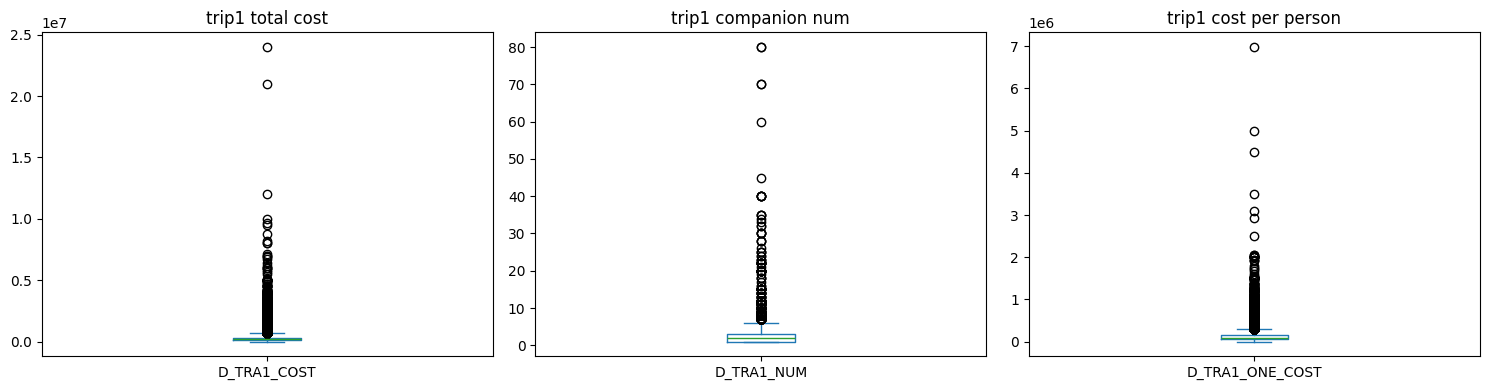

In [14]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
df['D_TRA1_COST'].dropna().plot(kind='box', ax=axes[0], title='trip1 total cost')
df['D_TRA1_NUM'].dropna().plot(kind='box', ax=axes[1], title='trip1 companion num')
df['D_TRA1_ONE_COST'].dropna().plot(kind='box', ax=axes[2], title='trip1 cost per person')
plt.tight_layout()
plt.show()

In [15]:
# 극단값 실제 확인 (동반인원 10명 이상)
df[df['D_TRA1_NUM'] >= 10][['연도','D_TRA1_NUM','D_TRA1_COST','D_TRA1_ONE_COST']]\
    .sort_values('D_TRA1_NUM', ascending=False).head(10)

,연도,D_TRA1_NUM,D_TRA1_COST,D_TRA1_ONE_COST
91480,2025,80,6000000,75000
52710,2025,80,24000000,300000
23172,2024,70,1400000,20000
11705,2024,70,2100000,30000
82466,2025,60,12000000,200000
22006,2024,45,4500000,100000
39203,2024,40,1100000,27500
97011,2025,40,5000000,125000
77632,2025,40,2000000,50000
39202,2024,40,1000000,25000


In [16]:
# COST = ONE_COST * NUM 산식이 실제로 맞는지 전체 회차 검증 (COST가 파생값이라 오류면 이상치일 가능성)
for n in range(1, 7):
    cost_c, one_c, num_c = f'D_TRA{n}_COST', f'D_TRA{n}_ONE_COST', f'D_TRA{n}_NUM'
    sub = df[df[cost_c].notnull()]
    diff = (sub[one_c] * sub[num_c] - sub[cost_c]).abs()
    print(f'{n}차 COST≠ONE_COST×NUM 불일치:', (diff > 1).sum(), '/', len(sub))

1차 COST≠ONE_COST×NUM 불일치: 0 / 53055
2차 COST≠ONE_COST×NUM 불일치: 0 / 3014
3차 COST≠ONE_COST×NUM 불일치: 0 / 210
4차 COST≠ONE_COST×NUM 불일치: 0 / 28
5차 COST≠ONE_COST×NUM 불일치: 0 / 7
6차 COST≠ONE_COST×NUM 불일치: 0 / 1


## 이상치 처리 전략

### 동반인원(`D_TRAn_NUM`) 및 경비(`D_TRAn_COST`) 극단값
- 처리: **삭제하지 않음(원본 유지), 분석 시 winsorize/log 변환 등으로 별도 대응**
- 근거: 모든 회차에서 `COST = ONE_COST × NUM`이 정확히 성립(불일치 0건)하여 오입력이 아니라 **단체여행(계 모임, 회사 워크숍 등)일 가능성이 높음**. 실제 값이므로 임의 삭제 시 정보 손실 위험이 큼. 다만 지역별 지출 총액 분석 시에는 소수의 초고액 단체 지출이 특정 지역 평균을 왜곡할 수 있어 스케일 처리(로그변환) 또는 중앙값 사용을 권장

## 4. 손상 레코드

In [17]:
# 완전 중복행 / ID 중복 확인
print('완전 중복행:', df.duplicated().sum(), '건')
print('ID 중복:', df['ID'].duplicated().sum(), '건')

완전 중복행: 0 건
ID 중복: 0 건


In [18]:
# 출발연도(D_TRAn_SYEAR)가 조사연도(연도)와 다른 경우 확인 (전체 회차)
syear_cols = [c for c in df.columns if c.endswith('_SYEAR')]
for c in syear_cols:
    sub = df[df[c].notnull()]
    mismatch = (sub[c] != sub['연도']).sum()
    print(c, '조사연도와 다른 건수:', mismatch, '/', len(sub))

D_TRA1_SYEAR 조사연도와 다른 건수: 0 / 53055
D_TRA2_SYEAR 조사연도와 다른 건수: 0 / 3014
D_TRA3_SYEAR 조사연도와 다른 건수: 0 / 210
D_TRA4_SYEAR 조사연도와 다른 건수: 0 / 28
D_TRA5_SYEAR 조사연도와 다른 건수: 0 / 7
D_TRA6_SYEAR 조사연도와 다른 건수: 0 / 1


In [19]:
# 지역 사전집계(국내_A_여행횟수/지출_관광전체) vs 회차별 합산값 정합성 확인
cnt_cols = [c for c in df.columns if c.startswith('국내_A_여행횟수')]
exp_cols = [c for c in df.columns if c.startswith('국내_A_여행지출')]
df['지역합_여행횟수'] = df[cnt_cols].sum(axis=1)
df['지역합_여행지출'] = df[exp_cols].sum(axis=1)

mismatch = df[df['회차_응답수'] != df['지역합_여행횟수']]
print('회차 응답수 ≠ 지역합 여행횟수 인 응답자:', len(mismatch), '명')

회차 응답수 ≠ 지역합 여행횟수 인 응답자: 7496 명


In [20]:
# 위 불일치의 원인 확인: 단순출장(D_TRAn_CASE == 5)만 다녀온 사람은 지역합계에서 제외되는지 검증
only_biz = df[(df['D_TRA1_CASE'] == 5) & (df['회차_응답수'] == 1)]
print('1차만 응답 & 단순출장(CASE=5)인 응답자:', len(only_biz), '명')
print('그 중 지역합 여행횟수가 0인 응답자:', (only_biz['지역합_여행횟수'] == 0).sum(), '명')

1차만 응답 & 단순출장(CASE=5)인 응답자: 921 명
그 중 지역합 여행횟수가 0인 응답자: 921 명


## 손상 레코드 처리 전략

### 완전 중복행 / ID 중복 / 출발연도(SYEAR) 불일치
- 처리: 해당 없음(모두 0건) → 별도 처리 불필요

### 회차 응답수 vs 지역 사전집계 불일치
- 처리: **손상 아님, 원본 유지 + 파생변수로 구분해서 사용**
- 근거: 지역 사전집계(`국내_A_여행횟수/지출_관광전체`)는 조사기관이 애초에 **'관광' 목적 여행만** 집계한 값이라, `D_TRAn_CASE==5`(단순출장)만 있는 응답자는 지역 집계에서 0으로 빠짐. 두 지표는 서로 다른 것을 재는 지표이므로 통일하지 않고 **분석 목적(관광 소비 vs 전체 이동)에 따라 구분해서 사용**

In [21]:
print('처리 전 행 수:', len(df))

# 검증 결과 삭제할 손상 레코드가 없으므로 원본 그대로 유지
print('최종 행 수:', len(df), '(삭제 없음)')

처리 전 행 수: 103939
최종 행 수: 103939 (삭제 없음)


## 5. 파생변수 생성

### 만들 파생변수 목록
| 파생변수명 | 만드는 방법 | 목적 |
|---|---|---|
| `회차_응답수` | 1~6차 중 `D_TRAn_CASE`가 결측이 아닌 회차 개수 (연도별 존재하는 컬럼만, 이미 위에서 생성) | 연간 국내여행 총 횟수(관광+출장 등 전체 목적 포함) |
| `HAS_TRAVEL` | `회차_응답수 > 0` | 연내 국내여행 경험 유무 |
| `지역합_여행횟수` / `지역합_여행지출` | 17개 지역 컬럼 합산 (이미 위에서 생성) | 관광 목적 총 방문횟수 / 총 지출 |
| `주요_방문지역` | 여행횟수 기준 응답자가 가장 많이 방문한 시도(관광 목적) | 지역별 방문 집중도 분석의 기준 변수 |
| `평균_1회_지출_관광` | `지역합_여행지출 / 지역합_여행횟수` | 응답자 1회 관광여행당 평균 지출 |
| `BAGE_LABEL`, `BSEX_LABEL`, `BINC1_LABEL` | 코드북 기준 라벨 매핑 | 시각화·리포트용 가독성 확보(원래 코드값은 유지) |

In [22]:
# HAS_TRAVEL: 연내 국내여행 경험 유무
df['HAS_TRAVEL'] = df['회차_응답수'] > 0
df['HAS_TRAVEL'].value_counts()

HAS_TRAVEL
True     53328
False    50611
Name: count, dtype: int64

In [23]:
# 주요_방문지역: 응답자별로 여행횟수(관광 목적)가 가장 많은 지역
region_names = [c.replace('국내_A_여행횟수_관광전체_', '') for c in cnt_cols]
region_cnt_df = df[cnt_cols].copy()
region_cnt_df.columns = region_names

def get_top_region(row):
    if row.sum() == 0:
        return np.nan
    return row.idxmax()

df['주요_방문지역'] = region_cnt_df.apply(get_top_region, axis=1)
df['주요_방문지역'].value_counts(dropna=True).head(10)

주요_방문지역
경기    6650
전남    5696
경남    4907
강원    4810
경북    4664
충남    4634
전북    3616
부산    2496
충북    2267
제주    1988
Name: count, dtype: int64

In [24]:
# 평균_1회_지출_관광: 응답자 1회 관광여행당 평균 지출 (여행 경험 없는 사람은 NaN)
df['평균_1회_지출_관광'] = np.where(
    df['지역합_여행횟수'] > 0,
    df['지역합_여행지출'] / df['지역합_여행횟수'],
    np.nan
)
df['평균_1회_지출_관광'].describe()

count    4.785200e+04
mean     1.333647e+05
std      1.472267e+05
min      1.000000e+03
25%      5.000000e+04
50%      8.750000e+04
75%      1.560000e+05
max      6.980000e+06
Name: 평균_1회_지출_관광, dtype: float64

In [25]:
# BSEX / BAGE / BINC1 라벨 매핑 (코드북 기준)
sex_map = {1: '남자', 2: '여자'}
age_map = {1: '15~19세', 2: '20대', 3: '30대', 4: '40대', 5: '50대', 6: '60대', 7: '70세 이상'}
inc_map = {1: '100만원 미만', 2: '100~200만원 미만', 3: '200~300만원 미만',
           4: '300~400만원 미만', 5: '400~500만원 미만', 6: '500~600만원 미만', 7: '600만원 이상'}

df['BSEX_LABEL'] = df['BSEX'].map(sex_map)
df['BAGE_LABEL'] = df['BAGE'].map(age_map)
df['BINC1_LABEL'] = df['BINC1'].map(inc_map)
df[['BSEX_LABEL','BAGE_LABEL','BINC1_LABEL']].head()

,BSEX_LABEL,BAGE_LABEL,BINC1_LABEL
0,남자,50대,600만원 이상
1,남자,40대,600만원 이상
2,남자,30대,400~500만원 미만
3,남자,40대,500~600만원 미만
4,여자,20대,600만원 이상


### 최종 구조
- 원본 82개 컬럼 + 파생변수 9개(`회차_응답수`, `HAS_TRAVEL`, `지역합_여행횟수`, `지역합_여행지출`, `주요_방문지역`, `평균_1회_지출_관광`, `BSEX_LABEL`, `BAGE_LABEL`, `BINC1_LABEL`) = 총 91개 컬럼
- 손상 레코드로 삭제된 행 없음 (103,939행 유지, 2024: 51,754 / 2025: 52,185)

In [26]:
print('최종 shape:', df.shape)
df.columns.tolist()

최종 shape: (103939, 91)


['ID',
 'WT_DOM',
 'BSEX',
 'BAGE',
 'BINC1',
 'D_TRA1_SYEAR',
 'D_TRA1_SMONTH',
 'D_TRA1_1_SPOT',
 'D_TRA1_CASE',
 'D_TRA1_COST',
 'D_TRA1_NUM',
 'D_TRA1_ONE_COST',
 'D_TRA2_SYEAR',
 'D_TRA2_SMONTH',
 'D_TRA2_1_SPOT',
 'D_TRA2_CASE',
 'D_TRA2_COST',
 'D_TRA2_NUM',
 'D_TRA2_ONE_COST',
 'D_TRA3_SYEAR',
 'D_TRA3_SMONTH',
 'D_TRA3_1_SPOT',
 'D_TRA3_CASE',
 'D_TRA3_COST',
 'D_TRA3_NUM',
 'D_TRA3_ONE_COST',
 'D_TRA4_SYEAR',
 'D_TRA4_SMONTH',
 'D_TRA4_1_SPOT',
 'D_TRA4_CASE',
 'D_TRA4_COST',
 'D_TRA4_NUM',
 'D_TRA4_ONE_COST',
 'D_TRA5_SYEAR',
 'D_TRA5_SMONTH',
 'D_TRA5_1_SPOT',
 'D_TRA5_CASE',
 'D_TRA5_COST',
 'D_TRA5_NUM',
 'D_TRA5_ONE_COST',
 'D_TRA6_SYEAR',
 'D_TRA6_SMONTH',
 'D_TRA6_1_SPOT',
 'D_TRA6_CASE',
 'D_TRA6_COST',
 'D_TRA6_NUM',
 'D_TRA6_ONE_COST',
 '국내_A_여행횟수_관광전체_서울',
 '국내_A_여행횟수_관광전체_부산',
 '국내_A_여행횟수_관광전체_대구',
 '국내_A_여행횟수_관광전체_인천',
 '국내_A_여행횟수_관광전체_광주',
 '국내_A_여행횟수_관광전체_대전',
 '국내_A_여행횟수_관광전체_울산',
 '국내_A_여행횟수_관광전체_세종',
 '국내_A_여행횟수_관광전체_경기',
 '국내_A_여행횟수_관광전체_강원',
 '국내_A_여행횟수_관광

## 6. 컬럼명 영문화 + 데이터 딕셔너리 생성
- 원본(raw) 파일의 한글 컬럼명은 코드북과 1:1 대조가 필요하니 그대로 두고, **cleaned 파일에서만 영어 snake_case로 rename**
- 이유: (1) matplotlib 기본 폰트가 한글을 지원 안 해서 시각화 시 글자가 깨짐, (2) 추후 챗봇 API/DB 연동 시 한글 컬럼명은 인코딩·따옴표 이슈가 생기기 쉬움
- **한글 → 영어 매핑을 딕셔너리(JSON)로 별도 저장**해서, 나중에 '이 영어 컬럼이 원래 뭐였는지' 언제든 역추적 가능하게 함

In [27]:
# 17개 시/도 한글 -> 영어 매핑 (지역 컬럼명 생성에 재사용)
region_en = {
    '서울': 'seoul', '부산': 'busan', '대구': 'daegu', '인천': 'incheon',
    '광주': 'gwangju', '대전': 'daejeon', '울산': 'ulsan', '세종': 'sejong',
    '경기': 'gyeonggi', '강원': 'gangwon', '충북': 'chungbuk', '충남': 'chungnam',
    '전북': 'jeonbuk', '전남': 'jeonnam', '경북': 'gyeongbuk', '경남': 'gyeongnam', '제주': 'jeju',
}

col_rename = {}
for kor_col in df.columns:
    if kor_col.startswith('국내_A_여행횟수_관광전체_'):
        region_kor = kor_col.replace('국내_A_여행횟수_관광전체_', '')
        col_rename[kor_col] = f'trip_cnt_{region_en[region_kor]}'
    elif kor_col.startswith('국내_A_여행지출_관광전체_'):
        region_kor = kor_col.replace('국내_A_여행지출_관광전체_', '')
        col_rename[kor_col] = f'trip_exp_{region_en[region_kor]}'

# 그 외 한글로 만든 컬럼(원본 파생변수 + 조사연도) 매핑
col_rename.update({
    '연도': 'year',
    '회차_응답수': 'trip_round_cnt',
    'HAS_TRAVEL': 'has_travel',
    '지역합_여행횟수': 'trip_cnt_total',
    '지역합_여행지출': 'trip_exp_total',
    '주요_방문지역': 'top_visited_region',
    '평균_1회_지출_관광': 'avg_exp_per_trip',
    'BSEX_LABEL': 'sex_label',
    'BAGE_LABEL': 'age_label',
    'BINC1_LABEL': 'income_label',
})

print('rename 대상 컬럼 수:', len(col_rename))

rename 대상 컬럼 수: 44


In [28]:
# rename 적용 (rename에 없는 컬럼 -> D_TRAn_*, BSEX, BAGE, BINC1, ID, WT_DOM 등은 원래 영어라 그대로 유지됨)
df = df.rename(columns=col_rename)
df.columns.tolist()

['ID',
 'WT_DOM',
 'BSEX',
 'BAGE',
 'BINC1',
 'D_TRA1_SYEAR',
 'D_TRA1_SMONTH',
 'D_TRA1_1_SPOT',
 'D_TRA1_CASE',
 'D_TRA1_COST',
 'D_TRA1_NUM',
 'D_TRA1_ONE_COST',
 'D_TRA2_SYEAR',
 'D_TRA2_SMONTH',
 'D_TRA2_1_SPOT',
 'D_TRA2_CASE',
 'D_TRA2_COST',
 'D_TRA2_NUM',
 'D_TRA2_ONE_COST',
 'D_TRA3_SYEAR',
 'D_TRA3_SMONTH',
 'D_TRA3_1_SPOT',
 'D_TRA3_CASE',
 'D_TRA3_COST',
 'D_TRA3_NUM',
 'D_TRA3_ONE_COST',
 'D_TRA4_SYEAR',
 'D_TRA4_SMONTH',
 'D_TRA4_1_SPOT',
 'D_TRA4_CASE',
 'D_TRA4_COST',
 'D_TRA4_NUM',
 'D_TRA4_ONE_COST',
 'D_TRA5_SYEAR',
 'D_TRA5_SMONTH',
 'D_TRA5_1_SPOT',
 'D_TRA5_CASE',
 'D_TRA5_COST',
 'D_TRA5_NUM',
 'D_TRA5_ONE_COST',
 'D_TRA6_SYEAR',
 'D_TRA6_SMONTH',
 'D_TRA6_1_SPOT',
 'D_TRA6_CASE',
 'D_TRA6_COST',
 'D_TRA6_NUM',
 'D_TRA6_ONE_COST',
 'trip_cnt_seoul',
 'trip_cnt_busan',
 'trip_cnt_daegu',
 'trip_cnt_incheon',
 'trip_cnt_gwangju',
 'trip_cnt_daejeon',
 'trip_cnt_ulsan',
 'trip_cnt_sejong',
 'trip_cnt_gyeonggi',
 'trip_cnt_gangwon',
 'trip_cnt_chungbuk',
 'trip_cnt

In [29]:
# 한글 원본명 -> 영어 컬럼명 매핑을 데이터 딕셔너리(JSON)로 저장
import json, os

PROCESSED_DIR = '../../data/processed'
PROCESSED_PATH = f'{PROCESSED_DIR}/eunyoung_combined_2024_2025_processed.csv'
DICT_PATH = f'{PROCESSED_DIR}/eunyoung_column_dictionary.json'

os.makedirs(PROCESSED_DIR, exist_ok=True)

with open(DICT_PATH, 'w', encoding='utf-8') as f:
    json.dump(col_rename, f, ensure_ascii=False, indent=2)

print('데이터 딕셔너리 저장 완료:', os.path.abspath(DICT_PATH))
print('저장된 매핑 개수:', len(col_rename))

데이터 딕셔너리 저장 완료: c:\Users\duath\Documents\Github\out-traveler\data\processed\eunyoung_column_dictionary.json
저장된 매핑 개수: 44


In [30]:
# 최종 processed 파일 저장 (컬럼명이 영어로 바뀐 최종본)
df.to_csv(PROCESSED_PATH, index=False)
print('저장 완료:', os.path.abspath(PROCESSED_PATH))
print('최종 shape:', df.shape)

저장 완료: c:\Users\duath\Documents\Github\out-traveler\data\processed\eunyoung_combined_2024_2025_processed.csv
최종 shape: (103939, 91)


## 7. 데이터 딕셔너리 불러오기 / 컬럼 검증 (사용 예시)
- 다른 노트북이나 나중에 다시 열었을 때, processed 파일의 영어 컬럼이 원래 뭐였는지, 또 딕셔너리와 실제 파일 컬럼이 어긋나지 않았는지 확인하는 방법

In [31]:
import json

# 1) 저장해둔 딕셔너리 불러오기
with open(DICT_PATH, encoding='utf-8') as f:
    col_dict = json.load(f)

print('딕셔너리 항목 수:', len(col_dict))
col_dict_rev = {v: k for k, v in col_dict.items()}
print("'trip_exp_jeju'의 원래 컬럼명:", col_dict_rev['trip_exp_jeju'])

딕셔너리 항목 수: 44
'trip_exp_jeju'의 원래 컬럼명: 국내_A_여행지출_관광전체_제주


In [32]:
# 2) processed 파일을 불러와서 딕셔너리와 컬럼이 실제로 일치하는지 검증
cleaned_combined = pd.read_csv(PROCESSED_PATH)

dict_english_cols = set(col_dict.values())
file_cols = set(cleaned_combined.columns)

missing_in_file = dict_english_cols - file_cols
print('딕셔너리에는 있는데 파일에 없는 컬럼:', missing_in_file if missing_in_file else '없음(정상)')

딕셔너리에는 있는데 파일에 없는 컬럼: 없음(정상)


# 📋 전처리 결과 요약

**데이터 소스**: `data/raw/combined_2024_2025.csv` (2024+2025 국민여행조사 통합본)
**최종 산출물**: `data/processed/eunyoung_combined_2024_2025_processed.csv`, `data/processed/eunyoung_column_dictionary.json`

## 1. 기본 정보
- 원본: 103,939행 × 82컬럼
- 결측치는 대부분 "진짜 결측"이 아니라 응답자가 해당 회차만큼 여행을 안 가서 생기는 구조적 결측으로 확인 (D_TRA1_CASE 응답 53,055명 → D_TRA6_CASE 응답 단 1명)
- 2024 데이터는 6차 여행 슬롯 자체가 없어 D_TRA6_* 전 항목이 2024 응답자 전원 결측인 것도 확인함

## 2. 타입 변환
- 회차별 필드(D_TRA1~6_SYEAR/SMONTH/1_SPOT/CASE/COST/NUM/ONE_COST) 42개 컬럼을 float → Int64(nullable)로 변환
- 태블로 시각화 시 `31030.0` 처럼 소수점 붙는 문제 해결
- WT_DOM, 지역별 지출 컬럼 등 진짜 실수값 컬럼은 float 그대로 유지

## 3. 이상치 검증
- D_TRA1_COST/NUM 극단값(동반인원 최대 80명, 경비 최대 2,400만원) 확인
- COST = ONE_COST × NUM 산식을 1~6차 전체 회차 전수 검증 → **불일치 0건** → 오입력 아니라 단체여행으로 판단, 삭제하지 않고 원본 유지

## 4. 손상 레코드 검증
- 완전 중복행 0건, ID 중복 0건
- 출발연도(SYEAR) ≠ 조사연도 불일치 1~6차 전체 0건
- 회차 응답수 vs 지역 사전집계 불일치 7,496명 발견 → 원인 검증 결과 "단순출장(CASE=5)만 다녀온 사람은 지역 집계(관광 목적만 집계)에서 제외"되는 게 원인으로 확인(921명 표본 검증) → 손상 아님, 원본 유지

## 5. 파생변수 생성 (9개)
`회차_응답수`, `HAS_TRAVEL`(여행경험 유무: True 53,328 / False 50,611), `지역합_여행횟수`, `지역합_여행지출`, `주요_방문지역`(1위 경기 6,650명), `평균_1회_지출_관광`(중앙값 87,500원), `BSEX_LABEL`, `BAGE_LABEL`, `BINC1_LABEL`

## 6. 컬럼명 영문화
- 한글 컬럼명 44개 → 영어 snake_case로 변환 (예: `국내_A_여행지출_관광전체_제주` → `trip_exp_jeju`)
- 매핑 정보는 `eunyoung_column_dictionary.json`으로 별도 저장, 원본 한글명 역추적 가능

## 7. 최종 저장 결과
- 최종 shape: **103,939행 × 91컬럼** (원본 82 + 파생변수 9)
- `eunyoung_combined_2024_2025_processed.csv` 저장 완료
- 딕셔너리-파일 컬럼 일치 검증 결과: **불일치 없음(정상)**